# EDA Seminario

## importacion de librerias

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
from scipy.signal import periodogram

In [2]:
import warnings
warnings.filterwarnings("ignore")

## Funciones 

In [3]:
def plot_series_brutas(df, variables, titulo_grupo):
    n = len(variables)
    fig, axes = plt.subplots(n, 1, figsize=(14, 2.5*n), sharex=True)
    if n == 1:
        axes = [axes]
    
    for ax, var in zip(axes, variables):
        ax.plot(df.index, df[var], linewidth=0.7, color="steelblue")
        
        # Línea de tendencia lineal encima
        x_num = np.arange(len(df))
        slope, intercept, r, p, _ = stats.linregress(x_num, df[var].values)
        tendencia = slope * x_num + intercept
        ax.plot(df.index, tendencia, color="red", linewidth=1.2,
                linestyle="--", label=f"tendencia (p={p:.3f})")
        
        ax.set_ylabel(var, fontsize=9)
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8, loc="upper right")
    
    fig.suptitle(f"Series temporales brutas — {titulo_grupo}", fontsize=13)
    axes[-1].set_xlabel("Tiempo")
    plt.tight_layout()
    plt.show()

In [4]:
def calcular_anomalias(df):
    """Resta la media mensual climatológica a cada observación."""
    clim_mensual = df.groupby(df.index.month).mean()
    anomalias = df.copy()
    for mes in range(1, 13):
        mask = df.index.month == mes
        anomalias.loc[mask] = df.loc[mask] - clim_mensual.loc[mes]
    return anomalias

In [5]:
def plot_anomalias(df_anom, variables, titulo_grupo):
    n = len(variables)
    fig, axes = plt.subplots(n, 1, figsize=(14, 2.5*n), sharex=True)
    if n == 1:
        axes = [axes]
    
    for ax, var in zip(axes, variables):
        vals = df_anom[var].values
        colores = np.where(vals >= 0, "tomato", "steelblue")
        
        # Bar plot: rojo = anomalía positiva, azul = negativa
        ax.bar(df_anom.index, vals, color=colores, width=20, linewidth=0)
        ax.axhline(0, color="black", linewidth=0.8)
        
        # Media móvil 12 meses para señal interanual
        mm12 = df_anom[var].rolling(12, center=True).mean()
        ax.plot(df_anom.index, mm12, color="black",
                linewidth=1.5, label="media móvil 12 m")
        
        ax.set_ylabel(var, fontsize=9)
        ax.grid(alpha=0.2)
        ax.legend(fontsize=8, loc="upper right")
    
    fig.suptitle(f"Anomalías respecto a climatología mensual — {titulo_grupo}", fontsize=13)
    axes[-1].set_xlabel("Tiempo")
    plt.tight_layout()
    plt.show()

In [6]:
def plot_ciclo_estacional(df, variables, titulo_grupo,meses_nombres):
    n = len(variables)
    ncols = min(2, n)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(7*ncols, 3.5*nrows))
    axes = np.array(axes).flatten()
    
    for ax, var in zip(axes, variables):
        por_mes = df.groupby(df.index.month)[var]
        media   = por_mes.mean()
        std     = por_mes.std()
        
        ax.fill_between(range(1, 13),
                        media - std, media + std,
                        alpha=0.25, color="steelblue", label="±1σ")
        ax.plot(range(1, 13), media,
                marker="o", color="steelblue", linewidth=2, label="media")
        
        ax.set_xticks(range(1, 13))
        ax.set_xticklabels(meses_nombres, fontsize=8)
        ax.set_title(var)
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)
    
    for ax in axes[n:]:
        ax.axis("off")
    
    fig.suptitle(f"Ciclo estacional con ±1σ — {titulo_grupo}", fontsize=13)
    plt.tight_layout()
    plt.show()

In [7]:
def boxplot_mensual(df, var):
    plt.figure(figsize=(10,4))
    sns.boxplot(
        x="month",
        y=var,
        data=df,
        showfliers=False
    )
    plt.title(f"Distribución mensual de {var}")
    plt.xlabel("Mes")
    plt.ylabel(var)
    plt.grid(alpha=0.3)
    plt.show()

In [8]:
def boxplots_grupo(df, variables, titulo):
    n = len(variables)
    fig, axes = plt.subplots(n, 1, figsize=(10, 3*n), sharex=True)
    if n == 1:
        axes = [axes]

    for ax, var in zip(axes, variables):
        sns.boxplot(
            x="month",
            y=var,
            data=df,
            showfliers=False,
            ax=ax
        )
        ax.set_title(var)
        ax.grid(alpha=0.3)

    fig.suptitle(titulo, fontsize=14)
    plt.tight_layout()
    plt.show()

## Cargado de datos

In [9]:
ds = xr.open_dataset("era5_caribe_mensual_1976_2025_UNIFICADO.nc")
print(ds)

<xarray.Dataset> Size: 877MB
Dimensions:    (step: 12, latitude: 73, longitude: 65, time: 600)
Coordinates:
    number     int64 8B ...
  * step       (step) timedelta64[ns] 96B 01:00:00 02:00:00 ... 12:00:00
    surface    float64 8B ...
  * latitude   (latitude) float64 584B 13.0 12.75 12.5 12.25 ... -4.5 -4.75 -5.0
  * longitude  (longitude) float64 520B -82.0 -81.75 -81.5 ... -66.25 -66.0
  * time       (time) datetime64[ns] 5kB 1976-01-01 1976-02-01 ... 2025-12-01
Data variables:
    u10        (time, latitude, longitude) float32 11MB ...
    v10        (time, latitude, longitude) float32 11MB ...
    t2m        (time, latitude, longitude) float32 11MB ...
    e          (time, step, latitude, longitude) float32 137MB ...
    msl        (time, latitude, longitude) float32 11MB ...
    sst        (time, latitude, longitude) float32 11MB ...
    slhf       (time, step, latitude, longitude) float32 137MB ...
    ssr        (time, step, latitude, longitude) float32 137MB ...
    ssrd 

**DICCIONARIO DE LAS VARIABLES**



    '10m_u_component_of_wind':          {'short_name': 'u10',  'alias': 'u10'},

    '10m_v_component_of_wind':          {'short_name': 'v10',  'alias': 'v10'},

    '2m_temperature':                    {'short_name': 't2m',  'alias': 't2m'},

    'evaporation':                       {'short_name': 'e',    'alias': 'e'},

    'mean_sea_level_pressure':           {'short_name': 'msl',  'alias': 'msl'},

    'sea_surface_temperature':           {'short_name': 'sst',  'alias': 'sst'},

    'surface_latent_heat_flux':          {'short_name': 'slhf', 'alias': 'slhf'},

    'surface_net_solar_radiation':       {'short_name': 'ssr',  'alias': 'ssr'},

    'surface_solar_radiation_downwards': {'short_name': 'ssrd', 'alias': 'ssrd'},

    'surface_thermal_radiation_downwards':{'short_name': 'strd','alias': 'strd'},

    'total_precipitation':               {'short_name': 'tp',   'alias': 'tp'},


**ESTRUCTURA VISIBLE DE LOS DATOS**

Es un dataset climático multidimensional proveniente de Copernicus Climate Change Service (ERA5), con:

- Cobertura temporal: 1976 → 2025 (600 meses)
- Resolución temporal: mensual
- Región: Caribe (incluye parte del norte de Sudamérica)

dimensiones son:

- time (600): tiempo (mensual)
- latitude (73): eje vertical del mapa
- longitude (65): eje horizontal del mapa
- step (12): step representa horizonte temporal dentro del mes

Coordenadas:
- latitude: 13 → -5 : Va de norte a sur (Caribe hacia zona ecuatorial)
- longitude: -82 → -66: Incluye Colombia, Caribe, parte de Centroamérica
- time: 1976-01 → 2025-12 → Serie temporal completa

Variables:

Variables sin **step**:
Estas dependen de:

(time, latitude, longitude)

- t2m → temperatura a 2m (variable objetivo)
- sst → temperatura superficial del mar
- msl → presión a nivel del mar
- u10, v10 → componentes del viento

Variables con **step**:
Estas dependen de:

(time, step, latitude, longitude)

- tp: precipitación
- ssr, ssrd: radiación solar
- strd: radiación térmica
- slhf: flujo de calor latente
- e: evaporación

Tamaño y complejidad:
- 877 MB
- Variables con step dominan el tamaño(computacional)

Variable Objetivo:

- Temperatura 2m (temperatura superficial)

**COSAS IMPORTANTES A NOTAR:**
- 3 Dimensiones:

-- Temporal

-- Espacial

-- Multivariables

- variables con y sin step (a la hora de tratar y analizar)
- La variabilidad es mensual
- Es un dataset local, evitar generalizaciones

## verificaciones iniciales de los datos

### 1. Integridad

**verificacion de valores faltantes**

In [10]:
for var in ds.data_vars:
    missing = ds[var].isnull().sum().item()
    print(f"{var}: {missing} valores faltantes")

u10: 0 valores faltantes
v10: 0 valores faltantes
t2m: 0 valores faltantes
e: 0 valores faltantes
msl: 0 valores faltantes
sst: 2010600 valores faltantes
slhf: 0 valores faltantes
ssr: 0 valores faltantes
ssrd: 0 valores faltantes
strd: 0 valores faltantes
tp: 0 valores faltantes


La variable sst presenta valores faltantes significativos (~2 millones), lo cual es consistente con su naturaleza física, ya que solo está definida sobre superficies oceánicas. No se identifican valores faltantes en las demás variables, lo que indica alta completitud del dataset.

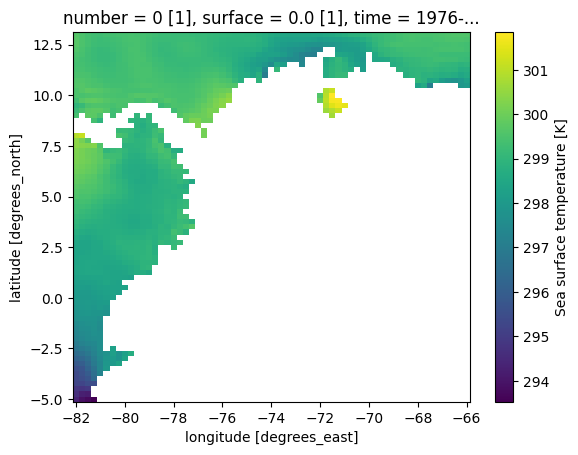

In [11]:
ds['sst'].isel(time=0).plot()

Como se puede ver en la grafica puesto que todo lo que no es mar se considera vacio

**Continuidad temporal**

In [12]:
import pandas as pd

time_diff = pd.Series(ds.time.values).diff().value_counts()
print(time_diff)

31 days    349
30 days    200
28 days     37
29 days     13
Name: count, dtype: int64


Esto es perfecto.

Refleja:

Meses reales del calendario:
- 31 días
- 30 días
- Febrero (28/29)

O sea:

- No hay saltos temporales
- No faltan meses

La serie temporal es continua y consistente con la estructura mensual del calendario, sin evidencia de datos faltantes o discontinuidades.

**Dimensiones consistentes**

In [13]:
for var in ds.data_vars:
    print(var, ds[var].dims)

u10 ('time', 'latitude', 'longitude')
v10 ('time', 'latitude', 'longitude')
t2m ('time', 'latitude', 'longitude')
e ('time', 'step', 'latitude', 'longitude')
msl ('time', 'latitude', 'longitude')
sst ('time', 'latitude', 'longitude')
slhf ('time', 'step', 'latitude', 'longitude')
ssr ('time', 'step', 'latitude', 'longitude')
ssrd ('time', 'step', 'latitude', 'longitude')
strd ('time', 'step', 'latitude', 'longitude')
tp ('time', 'step', 'latitude', 'longitude')


Las dimensiones de las variables son coherentes con su naturaleza física, diferenciando correctamente entre variables instantáneas y variables dependientes del horizonte temporal (step).

**Cobertura espacial completa**

In [14]:
print(ds.latitude.min().item(), ds.latitude.max().item())
print(ds.longitude.min().item(), ds.longitude.max().item())

-5.0 13.0
-82.0 -66.0


Esto coincide exactamente con:

region: Caribe

ademas que no hay cortes ni inconsistencias

**Conclusion integridad**

El dataset presenta una alta integridad estructural. No se identifican valores faltantes en la mayoría de las variables, con excepción de sst, cuyos valores faltantes son consistentes con su definición física (solo sobre océanos). La serie temporal es continua y respeta la periodicidad mensual del calendario. Las dimensiones de las variables son coherentes y la cobertura espacial corresponde correctamente a la región del Caribe sin inconsistencias.

### 2. Exactitud

In [15]:
def check_exactitud(ds):
    
    print("=== VERIFICACIÓN DE EXACTITUD ===")
    
    for var in ds.data_vars:
        data = ds[var]
        
        print(f"\nVariable: {var}")
        
        # Estadísticas básicas
        min_val = float(data.min())
        max_val = float(data.max())
        
        print(f"Min: {min_val}")
        print(f"Max: {max_val}")
        
        # --- Reglas físicas ---
        
        #  Temperatura (Kelvin)
        if var in ['t2m', 'sst']:
            invalid = ((data < 150) | (data > 350)).sum().item()
            print(f"Valores fuera de rango físico (150K - 350K): {invalid}")
        
        #  Precipitación
        elif var == 'tp':
            invalid = (data < 0).sum().item()
            print(f"Valores negativos (inválidos): {invalid}")
        
        #  Viento
        elif var in ['u10', 'v10']:
            invalid = (np.abs(data) > 150).sum().item()
            print(f"Valores extremos (>150 m/s): {invalid}")
        
        #  Presión
        elif var == 'msl':
            invalid = ((data < 80000) | (data > 120000)).sum().item()
            print(f"Valores fuera de rango (80000 - 120000 Pa): {invalid}")
        
        #  Radiación y flujos
        elif var in ['ssr', 'ssrd', 'strd', 'slhf']:
            invalid = (data < 0).sum().item()
            print(f"Valores negativos (posible error): {invalid}")
        
        #  Evaporación
        elif var == 'e':
            # Puede ser negativa (condensación), así que solo extremos
            invalid = (np.abs(data) > 1).sum().item()
            print(f"Valores extremos (>1 m de agua): {invalid}")
        
        else:
            print("No hay regla definida para esta variable")

In [16]:
check_exactitud(ds)

=== VERIFICACIÓN DE EXACTITUD ===

Variable: u10
Min: -12.790410041809082
Max: 7.410929203033447
Valores extremos (>150 m/s): 0

Variable: v10
Min: -9.319337844848633
Max: 8.784035682678223
Valores extremos (>150 m/s): 0

Variable: t2m
Min: 277.9945373535156
Max: 307.7173156738281
Valores fuera de rango físico (150K - 350K): 0

Variable: e
Min: -0.0003844672755803913
Max: 7.191924396465765e-06
Valores extremos (>1 m de agua): 0

Variable: msl
Min: 100633.5703125
Max: 102413.2578125
Valores fuera de rango (80000 - 120000 Pa): 0

Variable: sst
Min: 288.7977600097656
Max: 306.53436279296875
Valores fuera de rango físico (150K - 350K): 0

Variable: slhf
Min: -961469.9375
Max: 17982.09765625
Valores negativos (posible error): 34161568

Variable: ssr
Min: 2649.806396484375
Max: 1787591.75
Valores negativos (posible error): 0

Variable: ssrd
Min: 2883.0966796875
Max: 1852527.5
Valores negativos (posible error): 0

Variable: strd
Min: 911246.4375
Max: 1619786.5
Valores negativos (posible error

**Conclusion general Exactitud**
Las variables analizadas presentan valores dentro de rangos físicamente plausibles, sin evidencia de errores críticos como valores imposibles o inconsistentes. Las variables de temperatura, presión, viento y precipitación muestran comportamientos coherentes con la región del Caribe. Algunas variables de flujo energético, como slhf, presentan valores negativos debido a convenciones físicas y magnitudes elevadas asociadas a acumulaciones temporales, lo cual no constituye un error sino una característica del dataset.

### 3. Validez

**Tipos de datos**

In [17]:
for var in ds.data_vars:
    print(var, ds[var].dtype)

u10 float32
v10 float32
t2m float32
e float32
msl float32
sst float32
slhf float32
ssr float32
ssrd float32
strd float32
tp float32


Esto es exactamente lo esperado en datos climáticos.

**Coordenadas validas**

In [18]:
print(ds.latitude.values[:5])
print(ds.longitude.values[:5])

[13.   12.75 12.5  12.25 12.  ]
[-82.   -81.75 -81.5  -81.25 -81.  ]


Las coordenadas geográficas son válidas, consistentes y corresponden a una grilla regular sobre la región del Caribe. Se observa un orden descendente en latitud.

**Verificacion del tiempo**

In [19]:
print(ds.time.dtype)

datetime64[ns]


Esto es el estándar ideal en Python

**Conclusion general Validez**

El dataset cumple con los criterios de validez, presentando tipos de datos consistentes (float32) en todas las variables, adecuados para representar magnitudes físicas continuas. Las coordenadas espaciales son válidas y corresponden a una grilla regular dentro de los rangos geográficos esperados. La variable temporal se encuentra en formato datetime64[ns], lo que garantiza compatibilidad con herramientas de análisis temporal y permite realizar operaciones avanzadas sin inconvenientes.

**Conclusion final de la verificacion:**
- Integridad: Alta
- Exactitud: sin errores fisicos
- Validez: Estructura correcta

In [20]:
vars_era5 = list(ds.data_vars)

vars_era5

['u10', 'v10', 't2m', 'e', 'msl', 'sst', 'slhf', 'ssr', 'ssrd', 'strd', 'tp']

In [21]:
vars_no_step = ["t2m", "sst", "msl", "u10", "v10"]
vars_step = ["tp", "ssr", "ssrd", "strd", "slhf", "e"]

In [22]:
ds_step_monthly = ds[vars_step].sum(dim="step", skipna=True)
ds_full = xr.merge([ds[vars_no_step], ds_step_monthly])

In [23]:
ds_ts = ds_full.mean(dim=["latitude", "longitude"], skipna=True)
df_ts = ds_ts.to_dataframe().drop(columns=["number", "surface"], errors="ignore")
df_ts.index = pd.to_datetime(df_ts.index)

In [24]:
tiempo = df_ts.index
todas_vars = list(df_ts.columns)

## Dimension temporal

se realiza el analisis de las variables a nivel temporal, creando graficos temporales como series de tiempo, verificando si se tienen anomalias climaticas y la estacionalidad de las series de cada variable a lo largo del tiempo

In [25]:
grupos = {
    "Temperatura": ["t2m", "sst"],
    "Precipitación": ["tp"]
}

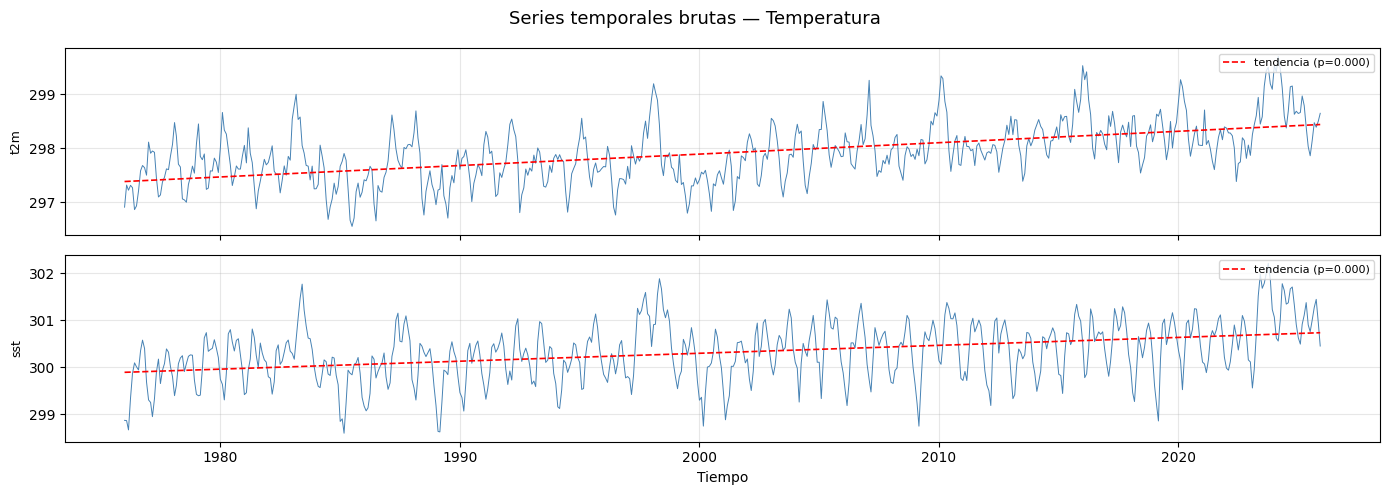

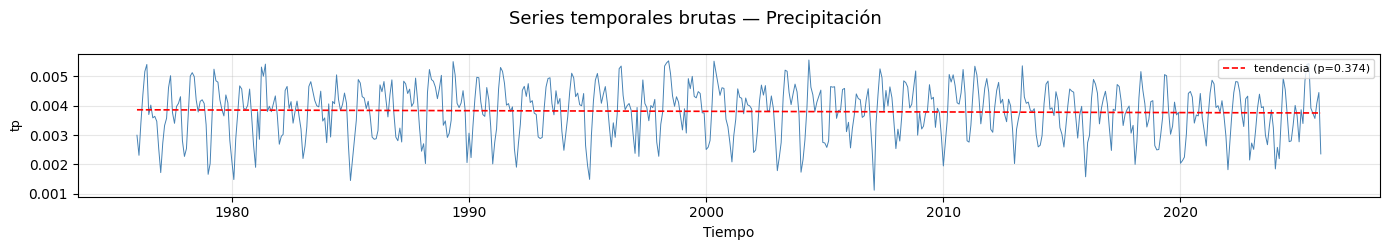

In [26]:
for nombre, vars_g in grupos.items():
    plot_series_brutas(df_ts, vars_g, nombre)

- Las variables de temperatura muestran la señal más robusta de cambio climático en el dataset.

    * **t2m (Temperatura a 2m) y sst (Temperatura superficial del mar):** Ambos indicadores presentan una **tendencia ascendente lineal** con un valor de p extremadamente bajo ($p=0.000$).
    * **Observación:** Se nota un incremento aproximado de 1°C entre el inicio y el final de la serie, con picos de calor cada vez más frecuentes e intensos en la última década (2015-2025).

* **tp (Precipitación total):** A diferencia de las variables térmicas, la precipitación no muestra una señal clara de cambio antropogénico en este dataset.
    * **Tendencia:** Presenta una **estabilidad interanual** con una pendiente prácticamente nula y un valor de p no significativo ($p=0.374$).
    * **Observación:** La serie está dominada por la **variabilidad natural y la estacionalidad**, manteniendo un rango de oscilación constante entre 0.001 y 0.005 unidades a lo largo de los 50 años registrados.
    * **Ciclos Extremos:** Aunque la media es estable, se identifican años con mínimos pluviométricos acentuados (posibles sequías) en periodos específicos como 1980, 2007 y 2021, sin que estos aumenten en frecuencia aparente.

In [27]:
df_anom = calcular_anomalias(df_ts)

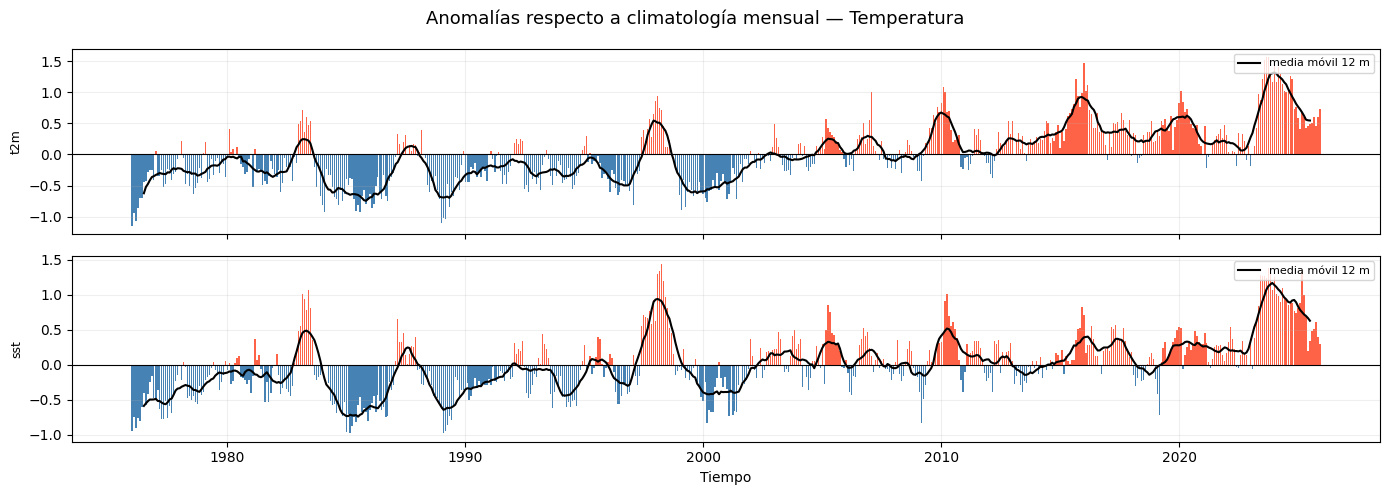

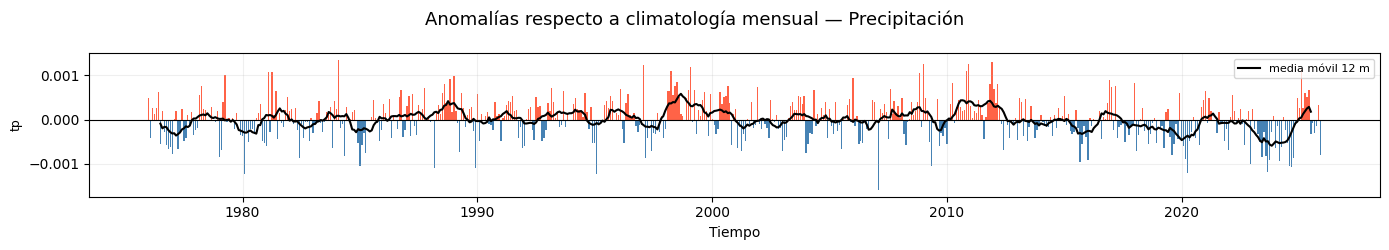

In [28]:
for nombre, vars_g in grupos.items():
    plot_anomalias(df_anom, vars_g, nombre)

- Tendencia de Temperaturas (t2m y sst): 
    Las gráficas de temperatura muestran una correlación casi perfecta entre la atmósfera y el océano, revelando un cambio estructural en el clima:

    * **Transición de Fase:** Se observa un cambio drástico de un predominio de anomalías negativas (barras azules) en las décadas de los 70 y 80, hacia un dominio absoluto de anomalías positivas (barras rojas) a partir del año 2000.
    * **Aceleración Reciente:** La **media móvil de 12 meses** (línea negra) muestra que el periodo 2023-2024 es el más cálido del registro, superando los $1.0^{\circ}C$ de anomalía.
    * **Eventos Cíclicos:** Los picos pronunciados coinciden con años de fuerte influencia de **El Niño** (1998, 2016, 2024).

- Comportamiento de la Precipitación (tp): 
    A diferencia de la temperatura, la precipitación presenta una señal mucho más volátil ("ruidosa"):

    * **Variabilidad Extrema:** No hay una tendencia lineal tan marcada, pero sí una mayor amplitud en las oscilaciones recientes.
    * **Relación Hídrica:** Los periodos de mayor temperatura suelen coincidir con picos de precipitación positiva, sugiriendo una intensificación del ciclo hidrológico en años cálidos.

In [29]:
meses_nombres = ["Ene","Feb","Mar","Abr","May","Jun",
                 "Jul","Ago","Sep","Oct","Nov","Dic"]

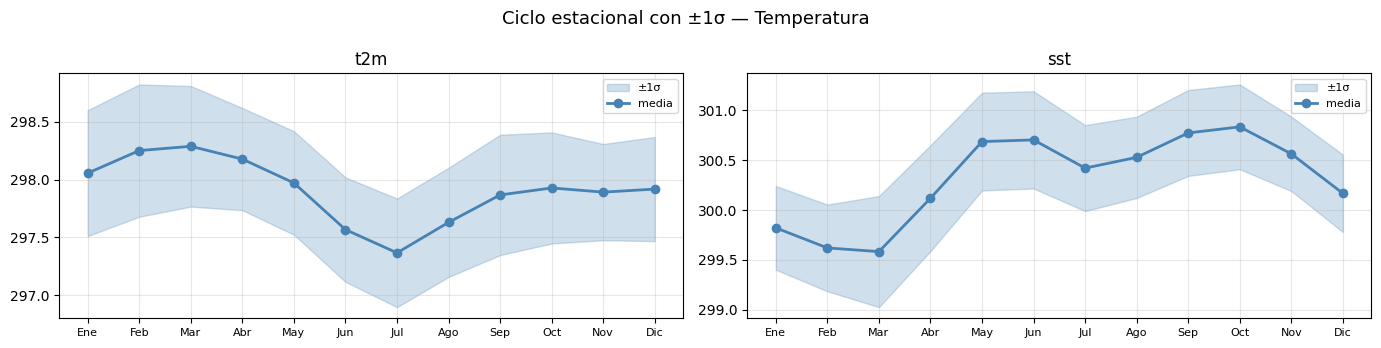

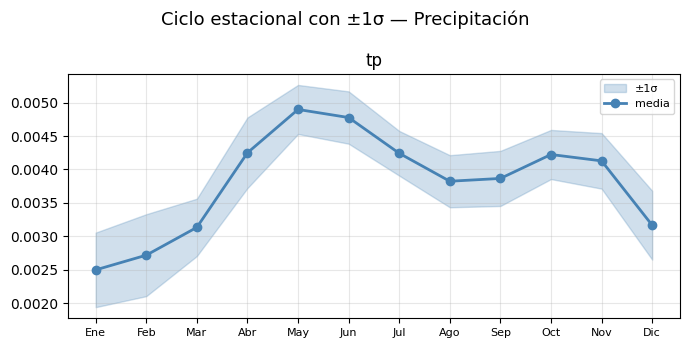

In [30]:
for nombre, vars_g in grupos.items():
    plot_ciclo_estacional(df_ts, vars_g, nombre,meses_nombres)

- Temperatura del Aire (t2m)
    * **Comportamiento Bimodal:** Presenta dos picos de calentamiento, siendo **marzo** el mes más caluroso ($~298.3 K$). 
    * **Mínimo Térmico:** Se observa un enfriamiento marcado que llega a su punto más bajo en **julio**.
    * **Variabilidad:** El sombreado ($\pm1\sigma$) es constante, lo que sugiere que la temperatura varía de forma similar año tras año.

- Temperatura superficial del mar (sst)
    * **Inercia y Desfase:** El mar alcanza su temperatura máxima en **mayo-junio** (posterior al pico del aire), superando los $300 K$.
    * **Evento de Enfriamiento:** Existe una caída notable en **julio**, posiblemente asociada a fenómenos de surgencia o cambios en corrientes superficiales.
    * **Influencia:** Los valores altos de SST coinciden con el inicio de la temporada de lluvias, actuando como fuente de energía y humedad.

- Precipitación Total (tp)
    * **Temporada de Lluvias:** El ciclo es claramente estacional. Las lluvias aumentan drásticamente en abril hasta alcanzar su **máximo en mayo**.
    * **La Canícula (Veranillo):** Se observa una disminución relativa de las lluvias en **agosto**, un fenómeno típico de regiones tropicales.
    * **Temporada Seca:** Los niveles más bajos de precipitación ocurren entre **enero y marzo**, coincidiendo con la fase de mayor radiación solar antes del pico térmico.

## Dimension Espacial

se realiza un analisis espacial con el analisis de mapas climatologicos y la variabilidad espacial de estos mapas, para analizar de esta manera el patron espacial promedio considerando todo el rango de tiempo

Los datos corresponden a promedios mensuales por año. 
Por tanto, los análisis espaciales representan climatologías 
multianuales de promedios mensuales, y la variabilidad temporal 
refleja cambios interanuales y estacionales combinados, no 
variabilidad de alta frecuencia (diaria u horaria).

**Mapas climatologicos por variable**

Realizamos mapas climatologicos mostrandolos de manera organizada para mayor facilidad de analisis

In [31]:
def detectar_dim(ds, claves):
    for d in ds.dims:
        if any(k in d.lower() for k in claves):
            return d
    return None

lat_dim  = detectar_dim(ds, ["lat"])
lon_dim  = detectar_dim(ds, ["lon"])
time_dim = detectar_dim(ds, ["time"])
step_dim = detectar_dim(ds, ["step"])

print(f"lat={lat_dim}, lon={lon_dim}, time={time_dim}, step={step_dim}")

lat=latitude, lon=longitude, time=time, step=step


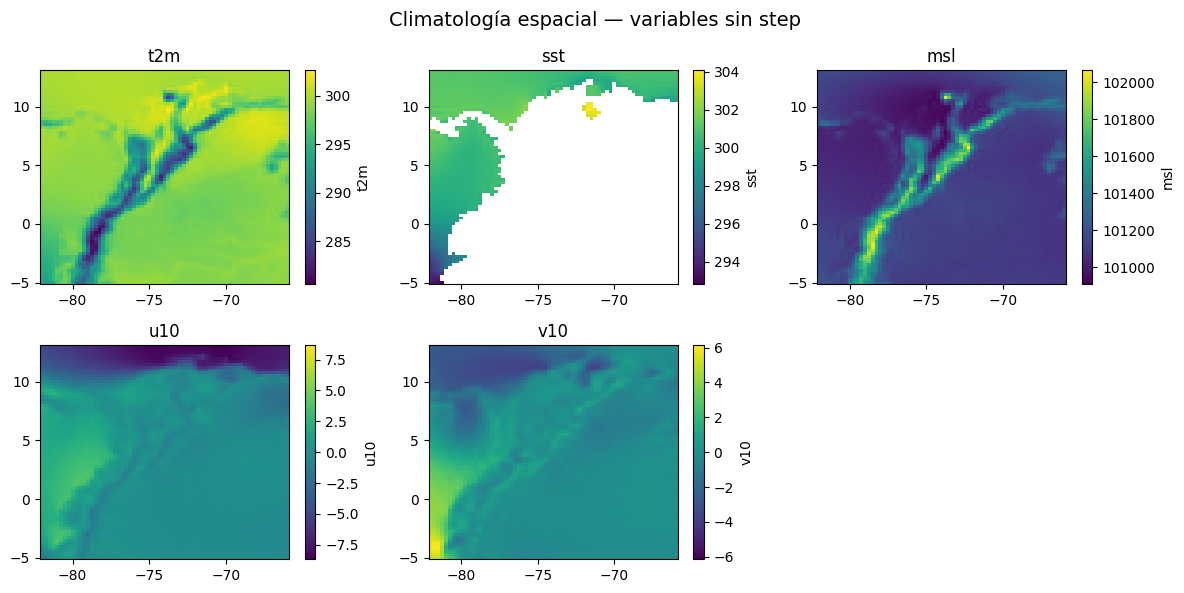

In [32]:
vars_no_step = ["t2m", "sst", "msl", "u10", "v10"]

ds_clim_no_step = ds[vars_no_step].mean(dim=time_dim, skipna=True)

ncols = 3
nrows = int(np.ceil(len(vars_no_step) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows))
axes = axes.flatten()

for ax, var in zip(axes, vars_no_step):
    da = ds_clim_no_step[var]
    da.plot(ax=ax, cmap="viridis", add_colorbar=True)
    ax.set_title(var)
    ax.set_xlabel("")
    ax.set_ylabel("")

# Ocultar ejes vacíos
for ax in axes[len(vars_no_step):]:
    ax.axis("off")

plt.suptitle("Climatología espacial — variables sin step", fontsize=14)
plt.tight_layout()
plt.show()

Las variables sin dimensión `step` representan estados instantáneos o promediables del sistema atmósfera–océano y permiten la construcción directa de mapas climatológicos mediante el promedio temporal del período de estudio.

- Temperatura a 2 m (`t2m`):
La climatología espacial de la temperatura a 2 m muestra un gradiente espacial coherente con la distribución regional de superficie continental y oceánica. Se observan valores más homogéneos sobre el océano y mayor variabilidad sobre zonas continentales, lo cual es físicamente consistente. La ausencia de discontinuidades o artefactos espaciales confirma la calidad del campo y su idoneidad como variable objetivo en etapas posteriores de modelado.

- Temperatura superficial del mar (`sst`):
El campo medio de la temperatura superficial del mar presenta una distribución suave y continua, con una clara delimitación entre regiones oceánicas y continentales. Este patrón confirma la correcta aplicación de la máscara tierra–mar en el dataset. Dado su carácter oceánico, esta variable no es directamente interpretable sobre tierra, lo cual debe considerarse en el preprocesamiento y selección de predictores.

- Presión a nivel del mar (`msl`):
La climatología de la presión a nivel del mar exhibe gradientes espaciales amplios y estructuras de gran escala, asociadas a patrones sinópticos persistentes. La baja variabilidad espacial relativa sugiere que esta variable actúa principalmente como un forzamiento de fondo, aportando contexto dinámico más que variabilidad local.

- Componentes del viento a 10 m (`u10`, `v10`):
Los mapas climatológicos de las componentes zonal y meridional del viento evidencian patrones direccionales bien definidos, coherentes con la circulación atmosférica regional del Caribe. La marcada anisotropía espacial sugiere que el viento no debe ser tratado como una variable escalar simple, sino preferiblemente mediante su magnitud y/o codificación direccional, con el fin de capturar adecuadamente su influencia en el sistema.


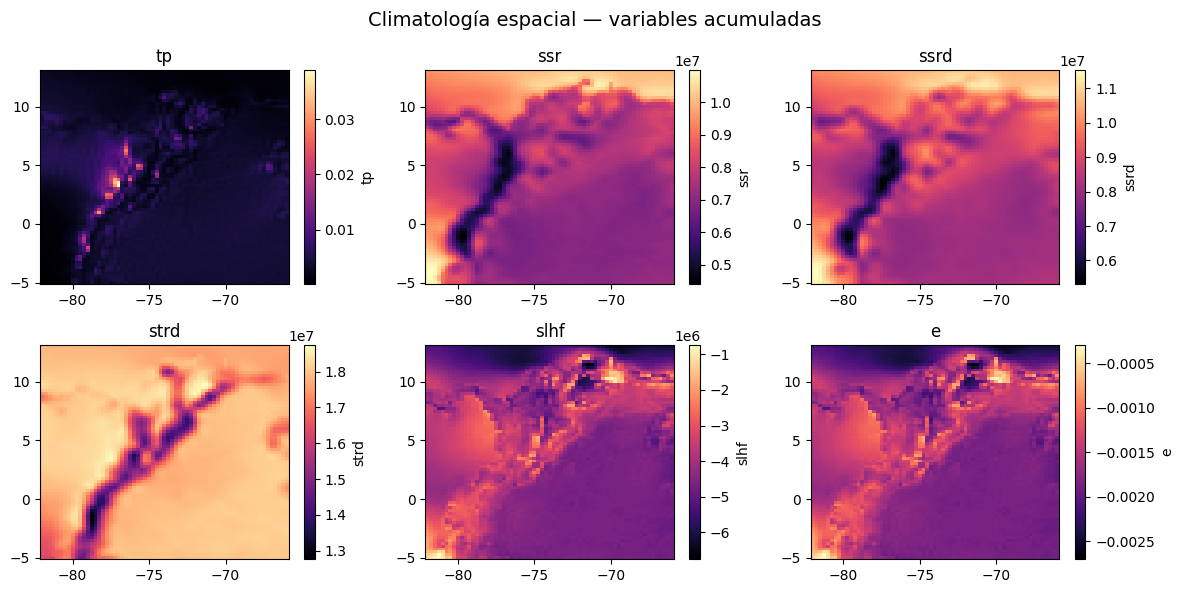

In [33]:
vars_step = ["tp", "ssr", "ssrd", "strd", "slhf", "e"]

ds_step_integrated = ds[vars_step].sum(dim=step_dim, skipna=True)
ds_clim_step = ds_step_integrated.mean(dim=time_dim, skipna=True)

ncols = 3
nrows = int(np.ceil(len(vars_step) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows))
axes = axes.flatten()

for ax, var in zip(axes, vars_step):
    da = ds_clim_step[var]
    da.plot(ax=ax, cmap="magma", add_colorbar=True)
    ax.set_title(var)
    ax.set_xlabel("")
    ax.set_ylabel("")

for ax in axes[len(vars_step):]:
    ax.axis("off")

plt.suptitle("Climatología espacial — variables acumuladas", fontsize=14)
plt.tight_layout()
plt.show()

Las variables con dimensión `step` representan acumulaciones o integrales temporales asociadas a flujos energéticos e hídricos. Para garantizar consistencia física, estas variables fueron integradas sobre la dimensión `step` antes del cálculo de la climatología espacial.

- Precipitación total (`tp`):
La climatología de la precipitación total revela una alta heterogeneidad espacial, caracterizada por núcleos intensos localizados y extensas regiones de baja precipitación media. Este comportamiento refleja la naturaleza intermitente y altamente no lineal de la precipitación, dominada por eventos extremos. En términos de modelado, esta variable puede requerir transformaciones adicionales (por ejemplo, escalas logarítmicas o discretización) para reducir su asimetría.

- Radiación solar (`ssr`, `ssrd`):
Los campos climatológicos de la radiación solar superficial muestran patrones espaciales muy similares entre sí, con gradientes suaves y alta coherencia regional. Esta similitud sugiere una fuerte correlación entre ambas variables, indicando redundancia informativa. En consecuencia, resulta metodológicamente razonable considerar la exclusión de una de ellas en etapas posteriores de selección de variables.

- Radiación térmica descendente (`strd`):
La radiación térmica descendente presenta un patrón espacial distinto al de la radiación solar, con una distribución estrechamente relacionada con la temperatura atmosférica y superficial. Esta variable constituye un componente clave del balance energético y se perfila como un predictor relevante para variables térmicas como `t2m`.

- Flujo de calor latente (`slhf`): 
El flujo de calor latente muestra valores predominantemente negativos, coherentes con la convención física asociada a la transferencia de energía desde la superficie hacia la atmósfera. Su alta variabilidad espacial refleja diferencias regionales en los procesos de evaporación y convección, destacando su importancia en la dinámica local del sistema.

- Evaporación (`e`): 
La climatología de la evaporación presenta patrones espaciales muy similares a los observados en el flujo de calor latente, diferenciándose principalmente por la escala de magnitud. Esta fuerte similitud indica una elevada correlación entre ambas variables, sugiriendo redundancia. Por tanto, no resulta necesario incluir simultáneamente ambas variables en el conjunto de predictores.

**Variabilidad espacial**

se verficia a su vez la variabilidad espacial para verificar donde varian mas las variables a nivel espacial y ver cuales son las zonas mas estables climaticamente

In [34]:
ds_std_no_step = ds[vars_no_step].std(dim=time_dim, skipna=True)

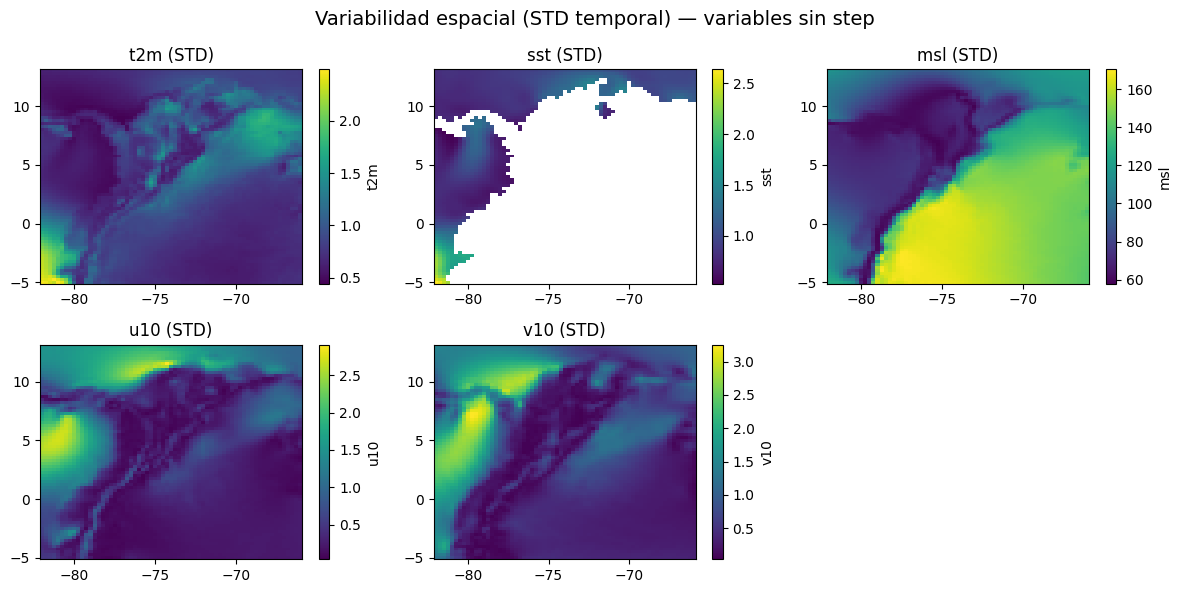

In [35]:
ncols = 3
nrows = int(np.ceil(len(vars_no_step) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows))
axes = axes.flatten()

for ax, var in zip(axes, vars_no_step):
    da = ds_std_no_step[var]
    da.plot(ax=ax, cmap="viridis", add_colorbar=True)
    ax.set_title(f"{var} (STD)")
    ax.set_xlabel("")
    ax.set_ylabel("")

for ax in axes[len(vars_no_step):]:
    ax.axis("off")

plt.suptitle("Variabilidad espacial (STD temporal) — variables sin step", fontsize=14)
plt.tight_layout()
plt.show()

### Variables sin step (instantáneas)

**`t2m` — Temperatura a 2 metros**  
La mayor variabilidad (STD ~2°C) se concentra en la zona andina y continental, lo cual es esperable: la orografía introduce fuertes gradientes térmicos. El océano exhibe STD baja, reflejando un comportamiento térmico más estable temporalmente.

**`sst` — Temperatura superficial del mar**  
Alta variabilidad en la costa pacífica colombiana y el norte del Caribe. La zona enmascarada en tierra es correcta. La variabilidad en el Pacífico Este tropical puede estar capturando señal de **ENSO** (variabilidad interanual).

**`msl` — Presión a nivel del mar**  
Patrón muy marcado: alta STD sobre tierra (especialmente Andes, >140 Pa) y baja en el Caribe abierto. Esto puede reflejar efectos orográficos y térmicos continentales, pero también puede constituir una **señal espuria** derivada de la reducción de presión al nivel del mar sobre topografía compleja. *Se recomienda verificar este comportamiento antes de usar `msl` como predictor en zonas de alta elevación.*

**`u10` / `v10` — Viento a 10 metros**  
Ambas componentes muestran alta variabilidad en la costa Pacífica y la franja ITCZ. La baja STD en el Caribe central confirma un régimen de **vientos alisios estable y persistente**. Notably, `v10` (componente meridional) presenta mayor variabilidad que `u10`, consistente con el desplazamiento N-S de la ITCZ a lo largo del año.

In [36]:
# Integrar acumulados
ds_step_integrated = ds[vars_step].sum(dim=step_dim, skipna=True)

# STD temporal
ds_std_step = ds_step_integrated.std(dim=time_dim, skipna=True)

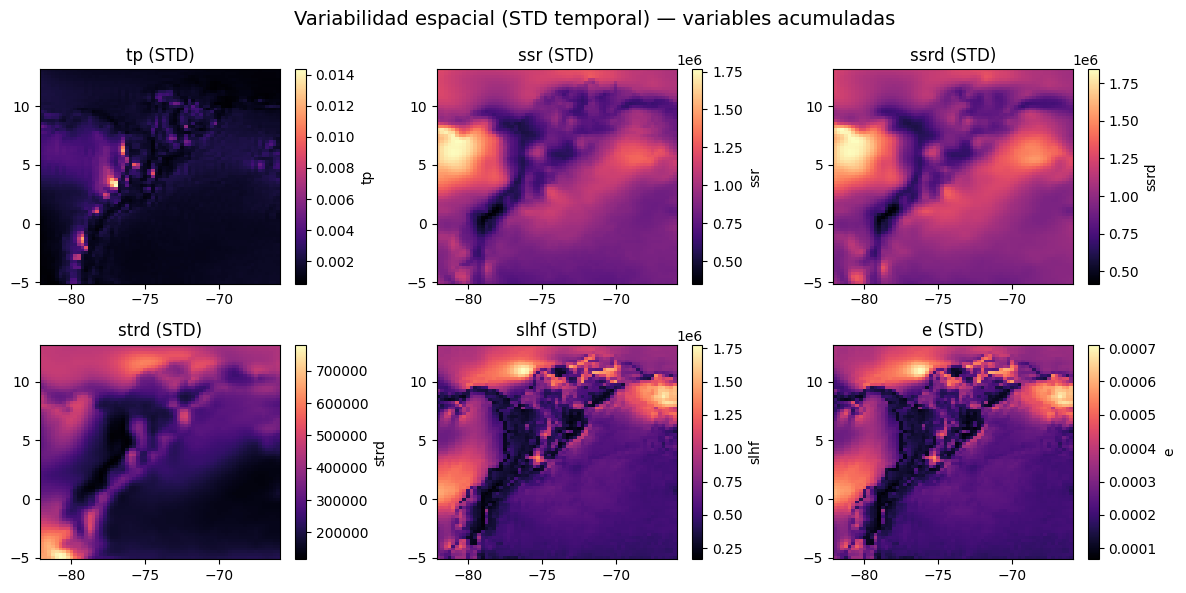

In [37]:
ncols = 3
nrows = int(np.ceil(len(vars_step) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows))
axes = axes.flatten()

for ax, var in zip(axes, vars_step):
    da = ds_std_step[var]
    da.plot(ax=ax, cmap="magma", add_colorbar=True)
    ax.set_title(f"{var} (STD)")
    ax.set_xlabel("")
    ax.set_ylabel("")

for ax in axes[len(vars_step):]:
    ax.axis("off")

plt.suptitle("Variabilidad espacial (STD temporal) — variables acumuladas", fontsize=14)
plt.tight_layout()
plt.show()

### Variables acumuladas
**`tp` — Precipitación total**  
STD muy alta y **espacialmente puntual sobre los Andes**, con un patrón pixelado característico de la convección orográfica intensa. La precipitación oceánica es más homogénea. Esta variable requiere tratamiento especial dada su naturaleza intermitente y distribución sesgada.

**`ssr` / `ssrd` — Radiación solar neta y descendente**  
Patrón suave y estructurado con máxima variabilidad en la franja tropical continental (~5°N). La gradiente N-S clara refleja el movimiento estacional de la **ITCZ** modulando la nubosidad. Ambas variables presentan patrones casi idénticos, indicando alta **colinealidad** entre ellas.

**`strd` — Radiación de onda larga descendente**  
Variabilidad moderada, mayor sobre tierra. Relacionada con variaciones de temperatura atmosférica y contenido de humedad en la columna.

**`slhf` — Flujo de calor latente superficial**  
Alta STD en zonas costeras y oceánicas tropicales, especialmente en el Pacífico. Conecta directamente con la variabilidad de SST y viento. Los mínimos sobre tierra sugieren que el flujo latente continental está más limitado por la disponibilidad de humedad del suelo.

**`e` — Evaporación**  
Patrón muy similar a `slhf`, lo cual es físicamente consistente (variables acopladas). Alta STD en el Pacífico Este tropical refuerza la posible huella de variabilidad interanual (ENSO).


## Dimension Multivariable

### Analisis univariado 

realizamos analisis univariado

In [38]:
df_ts.describe()

,t2m,sst,msl,u10,v10,tp,ssr,ssrd,strd,slhf,e
count,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,6.000000e+02,6.000000e+02,6.000000e+02,6.000000e+02,600.000000
mean,297.909607,300.318115,101147.546875,-0.742544,-0.278996,0.003810,7.693591e+06,8.685372e+06,1.761379e+07,-4.188290e+06,-0.001675
std,0.548682,0.619823,90.305794,0.466263,0.612235,0.000865,5.408206e+05,6.150406e+05,1.758951e+05,2.857795e+05,0.000114
min,296.549591,298.600647,100907.312500,-1.779237,-1.536195,0.001121,6.396513e+06,7.201546e+06,1.704058e+07,-4.849683e+06,-0.001939
25%,297.547256,299.910156,101085.119141,-1.101839,-0.866543,0.003213,7.310394e+06,8.259488e+06,1.752116e+07,-4.409025e+06,-0.001763
50%,297.869873,300.344269,101136.578125,-0.736899,-0.079616,0.003922,7.684014e+06,8.681974e+06,1.762778e+07,-4.176876e+06,-0.001670
75%,298.237640,300.734055,101209.017578,-0.397913,0.249479,0.004435,8.070790e+06,9.113400e+06,1.773584e+07,-3.960422e+06,-0.001584
max,299.697693,302.216858,101398.062500,0.582860,0.716381,0.005561,9.443648e+06,1.068164e+07,1.813644e+07,-3.562258e+06,-0.001424


realizamos boxplots a nivel mensual de cada una de las variables 

In [39]:
df_ts['month'] = df_ts.index.month

In [40]:
def boxplot_mensual(df, var):
    plt.figure(figsize=(10,4))
    sns.boxplot(
        x="month",
        y=var,
        data=df,
        showfliers=False
    )
    plt.title(f"Distribución mensual de {var}")
    plt.xlabel("Mes")
    plt.ylabel(var)
    plt.grid(alpha=0.3)
    plt.show()

In [41]:
def boxplots_grupo(df, variables, titulo):
    n = len(variables)
    fig, axes = plt.subplots(n, 1, figsize=(10, 3*n), sharex=True)
    if n == 1:
        axes = [axes]

    for ax, var in zip(axes, variables):
        sns.boxplot(
            x="month",
            y=var,
            data=df,
            showfliers=False,
            ax=ax
        )
        ax.set_title(var)
        ax.grid(alpha=0.3)

    fig.suptitle(titulo, fontsize=14)
    plt.tight_layout()
    plt.show()

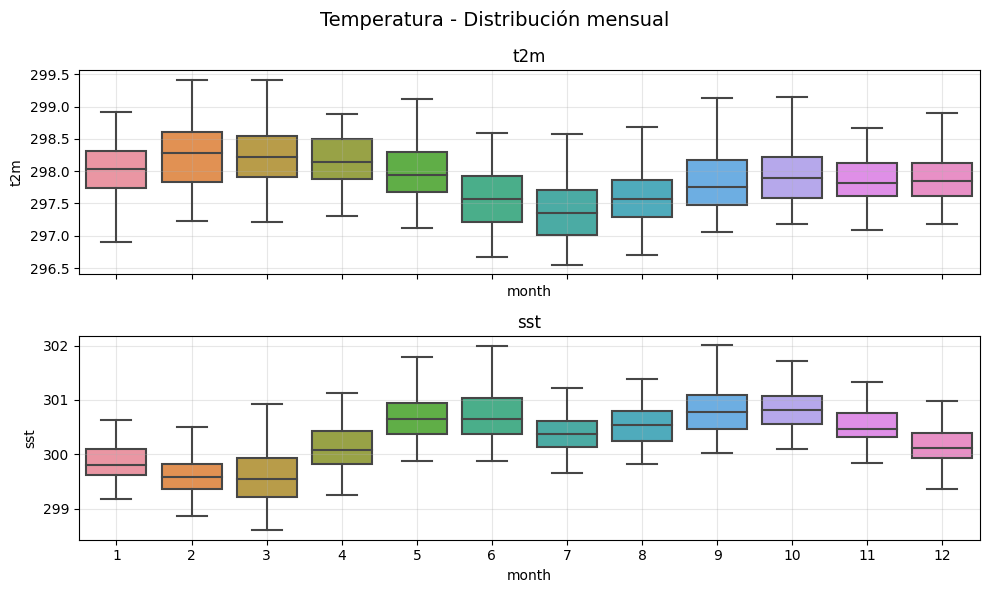

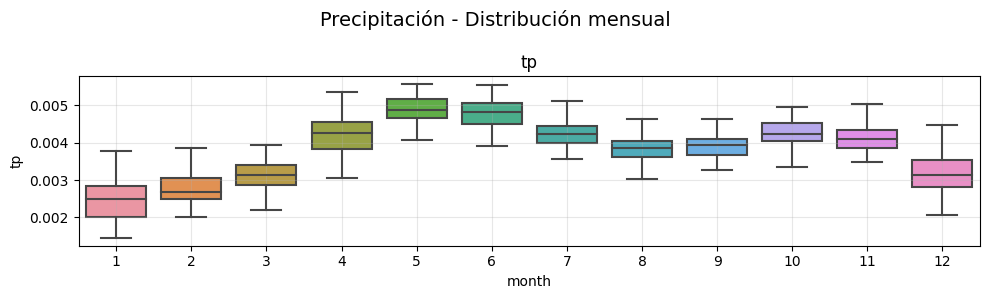

In [42]:
for grupo, vars_grupo in grupos.items():
    boxplots_grupo(
        df_ts,
        vars_grupo,
        f"{grupo} - Distribución mensual"
    )

Podemos observar que la mayoria de las variables tienen un comportamiento bastante similar entre grupos en la mayoria de los meses, y que no parece que se observan outliers o extremos en el dataset, pero esto se debe a que 

### Analisis outliers 

realizamos a su vez analisis de outlier, cuantificando los eventos extremos 

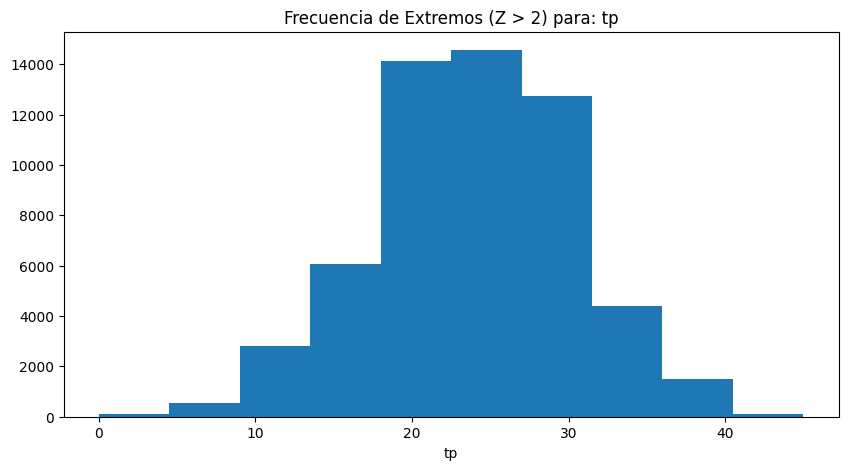

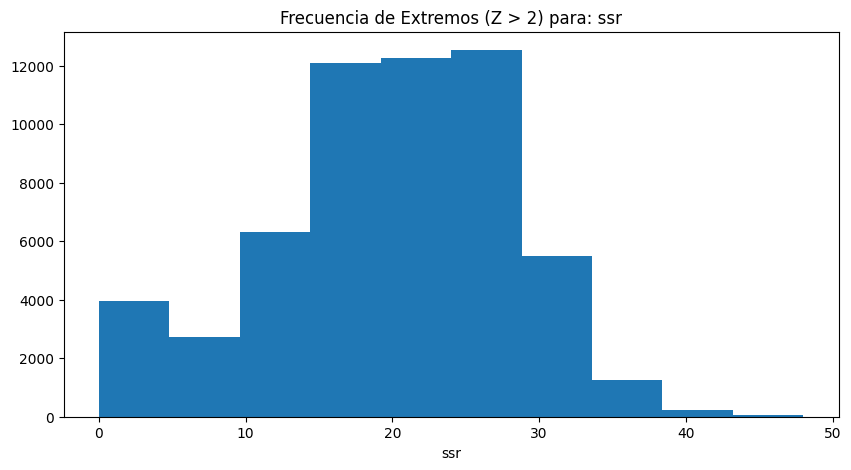

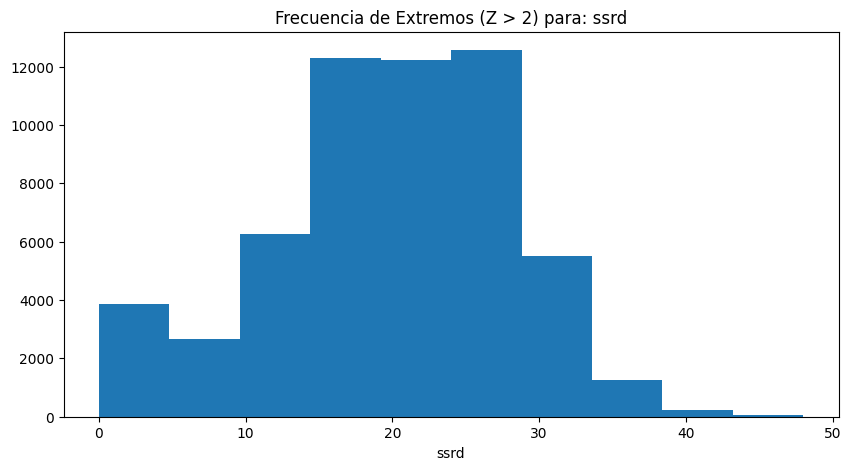

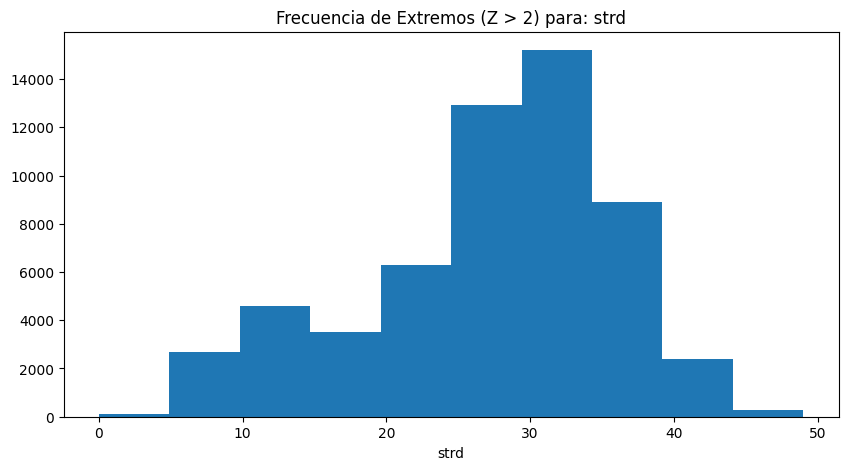

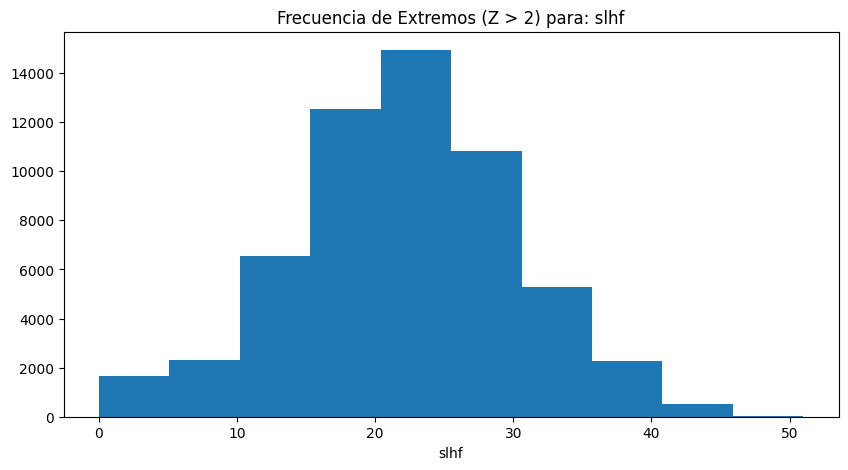

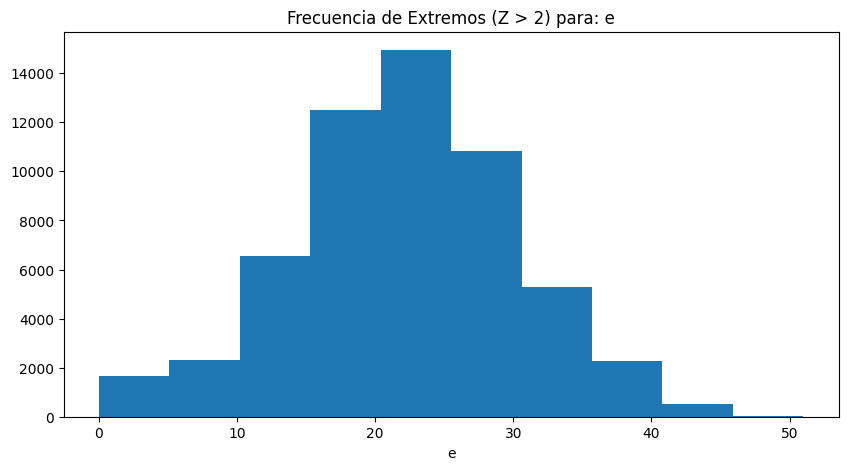

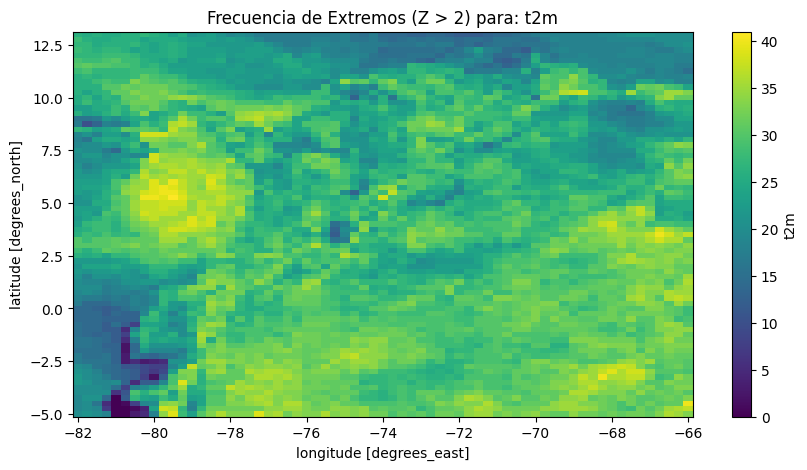

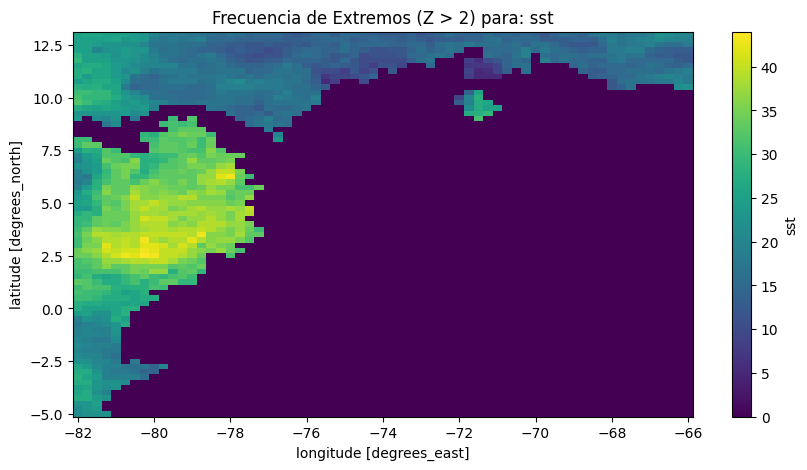

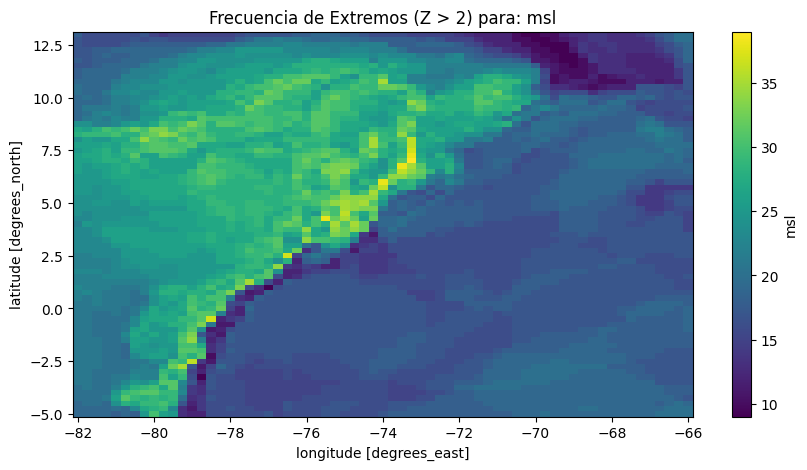

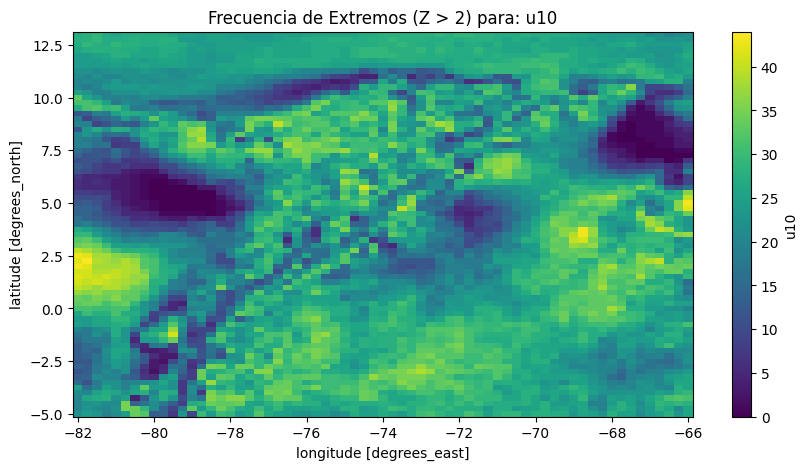

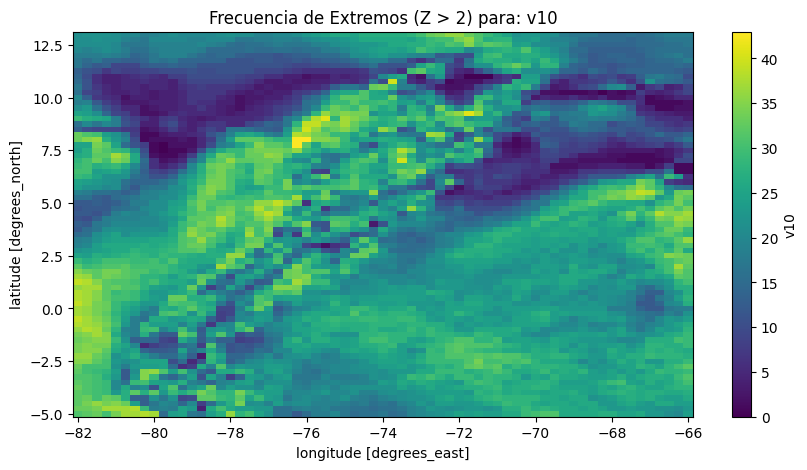

In [43]:
all_vars = vars_step + vars_no_step

resultados_extremos = {}
for var in all_vars:
    
    z_scores = (ds[var] - ds[var].mean('time')) / ds[var].std('time')
    
    extremos = z_scores.where(np.abs(z_scores) > 2)
    
    resultados_extremos[var] = extremos.count('time')
    
    plt.figure(figsize=(10, 5))
    resultados_extremos[var].plot()
    plt.title(f'Frecuencia de Extremos (Z > 2) para: {var}')
    plt.show()

### Correlaciones

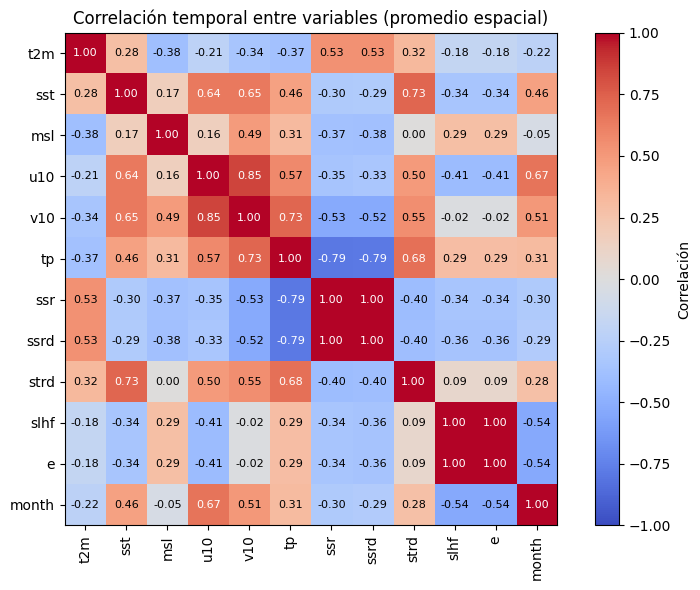

In [45]:
corr_matrix = df_ts.corr()
plt.figure(figsize=(8,6))
plt.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlación")
plt.xticks(range(len(corr_matrix)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix)), corr_matrix.columns)
plt.title("Correlación temporal entre variables (promedio espacial)")

# Anotar cada celda con su valor
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        valor = corr_matrix.iloc[i, j]
        color = "white" if abs(valor) > 0.6 else "black"  # contraste según intensidad
        plt.text(j, i, f"{valor:.2f}", ha="center", va="center", fontsize=8, color=color)

plt.tight_layout()
plt.show()

- Bloque radiativo y redundancia temporal

    Se observa una correlación prácticamente perfecta entre las variables radiativas `ssr` y `ssrd`, así como entre los flujos turbulentos `slhf` y `e`. Esta relación indica que dichas variables comparten esencialmente la misma señal temporal a escala mensual, lo que evidencia **redundancia informativa** en el contexto del EDA multivariable. Desde un punto de vista físico, esto es esperable dado que estas variables describen procesos energéticos estrechamente acoplados.

    En consecuencia, para análisis posteriores como reducción de dimensionalidad o modelado estadístico, resulta razonable considerar la selección de una variable representativa por cada par altamente correlacionado.

- Precipitación como variable integradora

    La precipitación total (`tp`) presenta correlaciones positivas moderadas a altas con las componentes del viento (`u10`, `v10`) y con la radiación de onda larga descendente (`strd`), mientras que muestra una fuerte correlación negativa con las variables radiativas de onda corta (`ssr`, `ssrd`). Este patrón sugiere que los meses más lluviosos están asociados a una mayor actividad dinámica y a una reducción de la radiación solar entrante, coherente con la presencia de nubosidad y procesos convectivos.

    En este sentido, `tp` actúa como una **variable integradora**, conectando la dinámica atmosférica con el balance energético del sistema.

- Temperatura y balance energético

    La temperatura a 2 metros (`t2m`) muestra correlaciones positivas con las variables radiativas y negativas con la precipitación y la presión a nivel del mar (`msl`). Este comportamiento indica que los meses más cálidos están asociados a mayores aportes radiativos y condiciones más secas, mientras que los meses más fríos coinciden con una mayor nubosidad y precipitación.

    Este patrón refuerza la interpretación de que la variabilidad térmica mensual está fuertemente controlada por el balance energético superficial.

- Rol modulador de la temperatura superficial del mar

    La temperatura superficial del mar (`sst`) presenta correlaciones positivas con las componentes del viento, la precipitación y la radiación de onda larga, lo que sugiere un papel activo del océano en la modulación de la dinámica atmosférica y de los flujos de energía. Dado el carácter costero de la región analizada, esta relación resulta físicamente consistente y destaca la importancia del acoplamiento océano-atmósfera en la variabilidad climática mensual.

- Dinámica atmosférica

    Las componentes zonal y meridional del viento (`u10` y `v10`) presentan una correlación elevada entre sí, indicando una estructura dinámica coherente. Además, ambas variables se relacionan de forma significativa con la precipitación y con variables energéticas, lo que sugiere que la circulación atmosférica superficial desempeña un papel clave en la organización de los regímenes mensuales.

- Presión a nivel del mar

    La presión a nivel del mar (`msl`) muestra correlaciones moderadas o débiles con la mayoría de las variables, lo que indica que actúa principalmente como una variable moduladora del sistema, más que como un factor dominante de la variabilidad mensual. No obstante, su relación negativa con la temperatura es consistente con la estructura estacional del clima regional.